# Step 2 — Mask preparation (MNI space)

Generates or standardises MNI-space masks for TUS targeting. Each method cell is
**independent** — run only the cells needed for the target region.  
All outputs land in `masks/standardized/` in `MNI152NLin2009cAsym` space (193 × 229 × 193, 1 mm iso),
matching the template used by step 3.

[← Step 1 — Segmentation](step01_segmentation_simnibs.ipynb) &nbsp;|&nbsp; **Step 2** &nbsp;|&nbsp; [Step 3 — Inverse Registration →](step03_inverse_registration.ipynb)

In [2]:
# Reference card — displays method overview and mask inventory.
# Run this cell once to see all options before running any method cell.
exec(open(__import__('pathlib').Path(__vsc_ipynb_file__).parent / 'z_references/step2_reference.py').read())


In [ ]:
# -----------------------------------------------------------------------
# Settings — edit here before running
# -----------------------------------------------------------------------

# Site configuration file (relative to this notebook or absolute path).
# Available: site_RIKEN_AK.yaml | site_UMD_AK.yaml | template_site.yaml
SITE_CONFIG = "../config/sites/site_UMD_AK.yaml"


In [2]:
# -----------------------------------------------------------------------
# Imports & path setup
# -----------------------------------------------------------------------

# ── Imports (stdlib) ──────────────────────────────────────
import sys
import os
import yaml
from pathlib import Path

NB_DIR = Path(__vsc_ipynb_file__).parent  # notebook directory (cwd-independent anchor)

# ── Imports (third-party) ─────────────────────────────────
import matplotlib
matplotlib.use("Agg")  # must be set BEFORE pyplot import
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import ants
from nilearn import plotting, image, datasets as nl_datasets
from templateflow.api import get as tf_get
from IPython.display import display, Image as IPImage

# ── Site config ───────────────────────────────────────────
_cfg_path = (NB_DIR / SITE_CONFIG).resolve()
with open(_cfg_path) as _f:
    site_cfg = yaml.safe_load(_f)

# Set NILEARN_DATA from atlases_dir (shell $NILEARN_DATA takes precedence if set).
_atlases = str(Path(site_cfg["atlases_dir"]).expanduser())
os.environ.setdefault("NILEARN_DATA", _atlases)

print(f"Site config:   {_cfg_path.name}  (site={site_cfg['site']}, station={site_cfg['station']})")
print(f"NILEARN_DATA:  {os.environ['NILEARN_DATA']}")

# ── Paths ─────────────────────────────────────────────────
MASKS_STANDARD_DIR = (NB_DIR / "../masks/standardized").resolve()
MASKS_ORIGINAL_DIR = (NB_DIR / "../masks/original").resolve()
MASKS_STANDARD_DIR.mkdir(exist_ok=True)

# ── MNI152NLin2009cAsym template (1 mm) ───────────────────
# Shared reference grid for all methods — same template used in step 3.
t1_mni_paths = tf_get("MNI152NLin2009cAsym", resolution=1, suffix="T1w", extension="nii.gz")
t1_mni_path  = str([p for p in t1_mni_paths if "desc-brain" not in str(p)][0])
t1_mni       = ants.image_read(t1_mni_path)
mni_nib      = nib.load(t1_mni_path)
mni_affine   = mni_nib.affine
mni_shape    = mni_nib.shape   # (193, 229, 193)

print(f"\nMNI template loaded: {Path(t1_mni_path).name}")
print(f"  Shape:   {mni_shape}")
print(f"  Spacing: {t1_mni.spacing}")
print(f"  Origin:  {t1_mni.origin}")
print(f"Output dir: {MASKS_STANDARD_DIR}")


Site config:   site_RIKEN_AK.yaml  (site=RIKEN, station=AK)
NILEARN_DATA:  /Users/atsushikikumoto/Dropbox/w_ONGOINGANY/atlases

MNI template loaded: tpl-MNI152NLin2009cAsym_res-01_T1w.nii.gz
  Shape:   (193, 229, 193)
  Spacing: (1.0, 1.0, 1.0)
  Origin:  (96.0, 132.0, -78.0)
Output dir: /Users/atsushikikumoto/Dropbox (Personal)/w_LABWORKS/PI/LabWiki/scripts/TUS/masks/standardized


In [40]:
# -----------------------------------------------------------------------
# Step 2a — NeuroSynth z-map + bounding box
# Creates a mask from a NeuroSynth association-test z-map, constrained
# within a hand-drawn bounding box in MNI152NLin2009cAsym space.
# Saves both the bounding box and the final z-map mask.
#
# Inputs:
#   masks/original/<NEUROSYNTH_FILE>
# Outputs:
#   masks/standardized/<LABEL>_bounding_box_mask_MNI.nii.gz
#   masks/standardized/<LABEL>_<NEUROSYNTH_LABEL>_mask_MNI.nii.gz
# -----------------------------------------------------------------------

# ─── SETTINGS ──────────────────────────────────────────────────────────
LABEL           = "aMCC"
NEUROSYNTH_FILE = "v5-topics-400_112_error_errors_monitoring_association-test_z_FDR_0.01.nii.gz"
NEUROSYNTH_LABEL = "NeuroSynthTopic112"   # used in output filename
Z_THRESHOLD     = 1.5                     # minimum z-stat to include voxel

# Bounding box in MNI mm coordinates (edit to adjust the aMCC extent).
# Convention: X = L(−) / R(+), Y = P(−) / A(+), Z = I(−) / S(+)
BBOX = {
    "x_min": -12,  "x_max":  12,   # medial wall (bilateral)
    "y_min":   5,  "y_max":  40,   # aMCC is anterior (positive Y)
    "z_min":  25,  "z_max":  55,   # dorsal extent
}

# ─── STEP 1: BOUNDING BOX MASK ─────────────────────────────────────────
# Build voxel → mm mapping for the MNI152NLin2009cAsym grid.
# mni_shape / mni_affine / mni_nib are defined in the Imports cell.
ii, jj, kk = np.meshgrid(
    np.arange(mni_shape[0]),
    np.arange(mni_shape[1]),
    np.arange(mni_shape[2]),
    indexing="ij",
)
ijk = np.column_stack((ii.ravel(), jj.ravel(), kk.ravel()))  # (N, 3)
xyz = nib.affines.apply_affine(mni_affine, ijk)              # (N, 3) mm

x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
in_bbox  = (
    (x >= BBOX["x_min"]) & (x <= BBOX["x_max"]) &
    (y >= BBOX["y_min"]) & (y <= BBOX["y_max"]) &
    (z >= BBOX["z_min"]) & (z <= BBOX["z_max"])
)
bbox_data = np.zeros(np.prod(mni_shape), dtype=np.uint8)
bbox_data[in_bbox] = 1
bbox_data = bbox_data.reshape(mni_shape)

hdr = mni_nib.header.copy()
hdr.set_data_dtype(np.uint8)
bbox_img  = nib.Nifti1Image(bbox_data, mni_affine, hdr)
bbox_img.set_sform(mni_affine, code=1)
bbox_img.set_qform(mni_affine, code=1)
bbox_path = MASKS_STANDARD_DIR / f"{LABEL}_bounding_box_mask_MNI.nii.gz"
nib.save(bbox_img, str(bbox_path))
print(f"Bounding box saved → {bbox_path.name}  ({int(bbox_data.sum())} voxels)")

# ─── STEP 2: NEUROSYNTH Z-MAP + BBOX INTERSECTION ──────────────────────
nsynth_src = MASKS_ORIGINAL_DIR / NEUROSYNTH_FILE
if not nsynth_src.exists():
    raise FileNotFoundError(
        f"NeuroSynth z-map not found: {nsynth_src}\n"
        f"Place it in masks/original/"
    )

# Load → reorient to RAS → resample to MNI152NLin2009cAsym 1mm grid
nsynth_ants  = ants.image_read(str(nsynth_src))
nsynth_ants  = ants.reorient_image2(nsynth_ants, orientation="RAS")
nsynth_ants  = ants.resample_image_to_target(nsynth_ants, t1_mni)

# Threshold z-map and intersect with bounding box
binary_nsynth = (nsynth_ants.numpy() > Z_THRESHOLD).astype(np.uint8)
final_mask    = (binary_nsynth & bbox_data).astype(np.uint8)

hdr2 = mni_nib.header.copy()
hdr2.set_data_dtype(np.uint8)
out_img = nib.Nifti1Image(final_mask, mni_affine, hdr2)
out_img.set_sform(mni_affine, code=1)
out_img.set_qform(mni_affine, code=1)
out_path = MASKS_STANDARD_DIR / f"{LABEL}_{NEUROSYNTH_LABEL}_mask_MNI.nii.gz"
nib.save(out_img, str(out_path))

print(f"\nNeuroSynth mask saved → {out_path.name}")
print(f"  z-threshold : {Z_THRESHOLD}")
print(f"  Voxels (z>thr in bbox): {int(final_mask.sum())}")


Bounding box saved → aMCC_bounding_box_mask_MNI.nii.gz  (17325 voxels)

NeuroSynth mask saved → aMCC_NeuroSynthTopic112_mask_MNI.nii.gz
  z-threshold : 1.5
  Voxels (z>thr in bbox): 0


In [35]:
# -----------------------------------------------------------------------
# Step 2b — Atlas-based ROI  (1/2): Select atlas and load label list
#
# Supported atlases (set ATLAS below):
#   "HO_cort"  — Harvard-Oxford cortical   (nilearn; auto-download)
#   "HO_sub"   — Harvard-Oxford subcortical (nilearn; auto-download)
#   "Juelich"  — Juelich cytoarchitectonic  (nilearn; auto-download)
#   "BN"       — Brainnetome 246-region     (local; requires $NILEARN_DATA/bn/)
#
# After running this cell, run the next cell to specify targets and build masks.
# -----------------------------------------------------------------------

# ─── SELECT ATLAS ──────────────────────────────────────────────────────
ATLAS = "BN"   # "HO_cort" | "HO_sub" | "Juelich" | "BN"

# BN atlas location (only used when ATLAS == "BN")
BN_ATLAS_DIR = Path(os.environ.get("NILEARN_DATA", "")) / "bn"

# ─── LOAD ──────────────────────────────────────────────────────────────
if ATLAS == "BN":
    bn_atlas_path = BN_ATLAS_DIR / "BN_Atlas_246_1mm.nii.gz"
    bn_lut_path   = BN_ATLAS_DIR / "BN_Atlas_246_LUT.txt"
    if not bn_atlas_path.exists():
        raise FileNotFoundError(
            f"BN atlas not found: {bn_atlas_path}\n"
            "Set $NILEARN_DATA to the directory containing bn/"
        )
    atlas_nib_ref = nib.as_closest_canonical(nib.load(str(bn_atlas_path)))
    atlas_data    = atlas_nib_ref.get_fdata()
    bn_lut        = np.loadtxt(str(bn_lut_path), dtype=str)
    atlas_ids     = bn_lut[:, 0].astype(int)
    atlas_labels  = bn_lut[:, 1].tolist()

elif ATLAS == "HO_cort":
    ho            = nl_datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-1mm")
    atlas_nib_ref = nib.load(ho.maps)
    atlas_data    = atlas_nib_ref.get_fdata()
    atlas_labels  = ho.labels     # index 0 = "Background"
    atlas_ids     = np.arange(len(atlas_labels))

elif ATLAS == "HO_sub":
    ho            = nl_datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-1mm")
    atlas_nib_ref = nib.load(ho.maps)
    atlas_data    = atlas_nib_ref.get_fdata()
    atlas_labels  = ho.labels
    atlas_ids     = np.arange(len(atlas_labels))

elif ATLAS == "Juelich":
    juelich       = nl_datasets.fetch_atlas_juelich("maxprob-thr25-1mm")
    atlas_nib_ref = nib.load(juelich.maps)
    atlas_data    = atlas_nib_ref.get_fdata()
    atlas_labels  = juelich.labels
    atlas_ids     = np.arange(len(atlas_labels))

else:
    raise ValueError(f"Unknown ATLAS: {ATLAS!r}. Choose from HO_cort, HO_sub, Juelich, BN.")

# ─── PRINT AVAILABLE LABELS ────────────────────────────────────────────
print(f"Atlas loaded: {ATLAS}  ({len(atlas_labels)} labels)\n")
for i, lbl in enumerate(atlas_labels):
    print(f"  {i:3d}  {lbl}")


Atlas loaded: BN  (247 labels)

    0  Unknown
    1  A8m_L
    2  A8m_R
    3  A8dl_L
    4  A8dl_R
    5  A9l_L
    6  A9l_R
    7  A6dl_L
    8  A6dl_R
    9  A6m_L
   10  A6m_R
   11  A9m_L
   12  A9m_R
   13  A10m_L
   14  A10m_R
   15  A9/46d_L
   16  A9/46d_R
   17  IFJ_L
   18  IFJ_R
   19  A46_L
   20  A46_R
   21  A9/46v_L
   22  A9/46v_R
   23  A8vl_L
   24  A8vl_R
   25  A6vl_L
   26  A6vl_R
   27  A10l_L
   28  A10l_R
   29  A44d_L
   30  A44d_R
   31  IFS_L
   32  IFS_R
   33  A45c_L
   34  A45c_R
   35  A45r_L
   36  A45r_R
   37  A44op_L
   38  A44op_R
   39  A44v_L
   40  A44v_R
   41  A14m_L
   42  A14m_R
   43  A12/47o_L
   44  A12/47o_R
   45  A11l_L
   46  A11l_R
   47  A11m_L
   48  A11m_R
   49  A13_L
   50  A13_R
   51  A12/47l_L
   52  A12/47l_R
   53  A4hf_L
   54  A4hf_R
   55  A6cdl_L
   56  A6cdl_R
   57  A4ul_L
   58  A4ul_R
   59  A4t_L
   60  A4t_R
   61  A4tl_L
   62  A4tl_R
   63  A6cvl_L
   64  A6cvl_R
   65  A1/2/3ll_L
   66  A1/2/3ll_R
   67  A4ll_L

In [36]:
# -----------------------------------------------------------------------
# Step 2b — Atlas-based ROI  (2/2): Specify targets and build masks
#
# Edit TARGET_LABELS below, then run this cell.
# Use " | " to union multiple labels into one mask (e.g. bilateral ROI).
# Label names must match exactly what was printed by the previous cell.
# Output: masks/standardized/{label}_{ATLAS}_mask_MNI.nii.gz
# -----------------------------------------------------------------------

# ─── SPECIFY TARGETS ───────────────────────────────────────────────────
TARGET_LABELS = [
    # BN insula subdivisions (bilateral):
    "dIa_L | dIa_R",                              # dorsal agranular insula
    "dId_L | dId_R",                              # dorsal dysgranular insula
    "dIg_L | dIg_R",                              # dorsal granular insula
    "vIa_L | vIa_R",                              # ventral agranular insula
    # BN OFC / hippocampus:
    "A13_L | A13_R",                              # orbitofrontal cortex area 13
    "rHipp_L | rHipp_R",                          # rostral hippocampus
    "cHipp_L | cHipp_R",                          # caudal hippocampus
]

# ─── BUILD ─────────────────────────────────────────────────────────────
mni_ref = nib.load(t1_mni_path)   # target grid: MNI152NLin2009cAsym 1mm

for target_label in TARGET_LABELS:
    roi_list = [lbl.strip() for lbl in target_label.split("|")]
    my_label = (target_label.strip()
                            .replace(" | ", "_OR_")
                            .replace("|", "OR")
                            .replace(" ", "_")
                            .replace(",", ""))

    missing = [lbl for lbl in roi_list if lbl not in atlas_labels]
    if missing:
        print(f"  SKIP {my_label}: labels not found in {ATLAS} — {missing}")
        continue

    # Build binary union mask in atlas space
    roi_mask = np.zeros(atlas_data.shape[:3], dtype=np.float32)
    for lbl in roi_list:
        idx      = atlas_labels.index(lbl)
        aid      = atlas_ids[idx]
        roi_mask = np.maximum(roi_mask, (atlas_data == aid).astype(np.float32))

    # Resample atlas space → MNI152NLin2009cAsym 1mm
    src_nii   = nib.Nifti1Image(roi_mask, atlas_nib_ref.affine)
    resampled = image.resample_to_img(src_nii, mni_ref, interpolation="nearest")
    mask      = (resampled.get_fdata() > 0).astype(np.uint8)

    # Save with MNI152NLin2009cAsym header
    hdr = mni_nib.header.copy()
    hdr.set_data_dtype(np.uint8)
    out_img = nib.Nifti1Image(mask, mni_affine, hdr)
    out_img.set_sform(mni_affine, code=1)
    out_img.set_qform(mni_affine, code=1)
    out_path = MASKS_STANDARD_DIR / f"{my_label}_{ATLAS}_mask_MNI.nii.gz"
    nib.save(out_img, str(out_path))

    print(f"  {my_label}")
    print(f"    Atlas:   {ATLAS}")
    print(f"    Labels:  {roi_list}")
    print(f"    Voxels:  {int(mask.sum())}")
    print(f"    Saved →  {out_path.name}")
    print()


  dIa_L_OR_dIa_R
    Atlas:   BN
    Labels:  ['dIa_L', 'dIa_R']
    Voxels:  3905
    Saved →  dIa_L_OR_dIa_R_BN_mask_MNI.nii.gz

  dId_L_OR_dId_R
    Atlas:   BN
    Labels:  ['dId_L', 'dId_R']
    Voxels:  5315
    Saved →  dId_L_OR_dId_R_BN_mask_MNI.nii.gz

  dIg_L_OR_dIg_R
    Atlas:   BN
    Labels:  ['dIg_L', 'dIg_R']
    Voxels:  4434
    Saved →  dIg_L_OR_dIg_R_BN_mask_MNI.nii.gz

  vIa_L_OR_vIa_R
    Atlas:   BN
    Labels:  ['vIa_L', 'vIa_R']
    Voxels:  3559
    Saved →  vIa_L_OR_vIa_R_BN_mask_MNI.nii.gz

  A13_L_OR_A13_R
    Atlas:   BN
    Labels:  ['A13_L', 'A13_R']
    Voxels:  13755
    Saved →  A13_L_OR_A13_R_BN_mask_MNI.nii.gz

  rHipp_L_OR_rHipp_R
    Atlas:   BN
    Labels:  ['rHipp_L', 'rHipp_R']
    Voxels:  8579
    Saved →  rHipp_L_OR_rHipp_R_BN_mask_MNI.nii.gz

  cHipp_L_OR_cHipp_R
    Atlas:   BN
    Labels:  ['cHipp_L', 'cHipp_R']
    Voxels:  9626
    Saved →  cHipp_L_OR_cHipp_R_BN_mask_MNI.nii.gz



In [ ]:
# -----------------------------------------------------------------------
# Step 2c — Pre-existing file ROI → MNI152NLin2009cAsym
# Loads a NIfTI mask from masks/original/, reorients to RAS, and
# resamples to the pipeline standard grid (193×229×193, 1 mm iso).
# Use for manually curated or atlas-specific files: BNST, CeA, LC, etc.
#
# Optional keys per entry:
#   threshold  : binarise as data > threshold  (default 0)
#   label_id   : binarise as data == label_id  (takes priority over threshold)
#   hemisphere : "L" or "R" — intersect with MNI_hemispheres_BN_1mm.nii.gz
#                (L = ID 1, R = ID 2)
# Output: {label}_mask_MNI.nii.gz
# -----------------------------------------------------------------------

# ─── SETTINGS ──────────────────────────────────────────────────────────
FILE_MASKS = {
    "BST_BNST": {
        "file": "Blackford_BNST_3T_ANTS_081216_2mm_6467to0_noCSF_bin_20220923.nii.gz",
        "threshold": 0,
        "description": "Bed Nucleus of the Stria Terminalis (Blackford 2022)",
    },
    "Ce_CeA": {
        "file": "CIT168_both_1mm_MNI_partial_vol_matched_2mmResize_BilatCeA.nii.gz",
        "threshold": 0,
        "description": "Central Nucleus of the Amygdala (CIT168 atlas)",
    },
    "LC": {
        "file": "metaMask_Dahl2022/LCmetaMask_MNI05_s01f_plus50.nii.gz",
        "threshold": 0,
        "description": "Locus Coeruleus bilateral meta-mask (Dahl et al. 2022, 0.5mm FSL MNI → resampled)",
    },
    # ── Maass et al. 2015 EC masks ────────────────────────────────────
    "alEC_PRCpref_left_Maass2015": {
        "file": "Maass2015/alEC_PRCpref_left_MNI.nii",
        "threshold": 0,
        "description": "alEC PRC-preferring (left), Maass et al. 2015",
    },
    "alEC_PRCpref_right_Maass2015": {
        "file": "Maass2015/alEC_PRCpref_right_MNI.nii",
        "threshold": 0,
        "description": "alEC PRC-preferring (right), Maass et al. 2015",
    },
    "pmEC_PHCpref_left_Maass2015": {
        "file": "Maass2015/pmEC_PHCpref_left_MNI.nii",
        "threshold": 0,
        "description": "pmEC PHC-preferring (left), Maass et al. 2015",
    },
    "pmEC_PHCpref_right_Maass2015": {
        "file": "Maass2015/pmEC_PHCpref_right_MNI.nii",
        "threshold": 0,
        "description": "pmEC PHC-preferring (right), Maass et al. 2015",
    },
    # ── Weizhen anterior hippocampus ─────────────────────────────────
    # Note: both thresholds yield left-hemisphere-only masks.
    # Right anterior hippocampus is not significant at either threshold.
    "hippocampus_anterior_L_Weizhen_0.01": {
        "file": "Weizhen_Hipp_mask_0.01.nii",
        "label_id": 5,
        "hemisphere": "L",
        "description": "Anterior hippocampus (left), Weizhen 2024 (cluster-α=0.01, label ID=5)",
    },
    "hippocampus_anterior_L_Weizhen_0.05": {
        "file": "WeizhenHipp_mask_0.05.nii",
        "label_id": 7,
        "hemisphere": "L",
        "description": "Anterior hippocampus (left), Weizhen 2024 (cluster-α=0.05, label ID=7) — fallback",
    },
}

BUILD_FILE_MASKS = [
    "hippocampus_anterior_L_Weizhen_0.01",
    "hippocampus_anterior_L_Weizhen_0.05",
]   # set to list(FILE_MASKS.keys()) to rebuild all


# ─── BUILD ─────────────────────────────────────────────────────────────
# Hemisphere mask (MNI_hemispheres_BN_1mm.nii.gz): L = ID 1, R = ID 2
_hemi_path = MASKS_STANDARD_DIR / "MNI_hemispheres_BN_1mm.nii.gz"
_hemi_ids  = {"L": 1, "R": 2}

for label, cfg in FILE_MASKS.items():
    if label not in BUILD_FILE_MASKS:
        continue
    src = MASKS_ORIGINAL_DIR / cfg["file"]
    if not src.exists():
        print(f"  SKIP {label}: {src.name} not found in masks/original/")
        continue

    # Load → reorient to RAS → resample to MNI152NLin2009cAsym 1mm grid
    tmp = ants.image_read(str(src))
    tmp = ants.reorient_image2(tmp, orientation="RAS")
    tmp = ants.resample_image_to_target(tmp, t1_mni, interp_type="nearestNeighbor")

    # Binarise: label_id (==) takes priority over threshold (>)
    if "label_id" in cfg:
        mask = (tmp.numpy() == cfg["label_id"]).astype(np.uint8)
    else:
        mask = (tmp.numpy() > cfg.get("threshold", 0)).astype(np.uint8)

    # Optional hemisphere intersection
    if "hemisphere" in cfg:
        hemi_id   = _hemi_ids[cfg["hemisphere"]]
        hemi_data = nib.load(str(_hemi_path)).get_fdata()
        mask      = (mask & (hemi_data == hemi_id)).astype(np.uint8)

    # Save with MNI152NLin2009cAsym header
    hdr = mni_nib.header.copy()
    hdr.set_data_dtype(np.uint8)
    out_img = nib.Nifti1Image(mask, mni_affine, hdr)
    out_img.set_sform(mni_affine, code=1)
    out_img.set_qform(mni_affine, code=1)
    out_path = MASKS_STANDARD_DIR / f"{label}_mask_MNI.nii.gz"
    nib.save(out_img, str(out_path))

    print(f"  {label}  ({cfg['description']})")
    print(f"    Source:  {src.name}")
    if "label_id" in cfg:
        print(f"    Label ID: {cfg['label_id']}")
    if "hemisphere" in cfg:
        print(f"    Hemi:    {cfg['hemisphere']}")
    print(f"    Voxels:  {int(mask.sum())}")
    print(f"    Saved →  {out_path.name}")
    print()

In [ ]:
# -----------------------------------------------------------------------
# Step 2d — Coordinate sphere (CSphere) mask generation
# Creates binary sphere masks at MNI mm coordinates in MNI152NLin2009cAsym.
# Each sphere is saved as {region}_CSphere_mask_MNI.nii.gz.
# -----------------------------------------------------------------------

# ─── ADD NEW REGIONS HERE ──────────────────────────────────────────────
SPHERE_REGIONS = {
    # coords_mm: list of (x, y, z) MNI coordinates (L then R by convention).
    # All centres are combined via OR into a single bilateral mask.
    # radius_mm: sphere radius in mm.
    "IFJ": {
        "coords_mm" : [(-42, 6, 30), (46, 12, 28)],
        "radius_mm" : 8.0,
        "description": "Inferior Frontal Junction (Derrfuss et al.)",
    },
    "FEF": {
        "coords_mm" : [(-28, -6, 54), (30, -6, 50)],
        "radius_mm" : 8.0,
        "description": "Frontal Eye Field (coordinate-based)",
    },
}

# Select which regions to build (subset or all).
BUILD_REGIONS = list(SPHERE_REGIONS.keys())   # e.g. ["IFJ"] to build one only

# ─── BUILD ─────────────────────────────────────────────────────────────
# Pre-compute voxel → mm mapping once for the MNI152NLin2009cAsym grid.
ii, jj, kk = np.meshgrid(
    np.arange(mni_shape[0]),
    np.arange(mni_shape[1]),
    np.arange(mni_shape[2]),
    indexing="ij",
)
ijk = np.column_stack((ii.ravel(), jj.ravel(), kk.ravel()))  # (N, 3)
xyz = nib.affines.apply_affine(mni_affine, ijk)              # (N, 3) in mm

# Brain mask: exclude background voxels of the MNI template.
brain_mask = (mni_nib.get_fdata() > 0).astype(np.uint8)

for region in BUILD_REGIONS:
    cfg     = SPHERE_REGIONS[region]
    centers = cfg["coords_mm"]
    r       = cfg["radius_mm"]

    # Build union of spheres.
    mask = np.zeros(mni_shape, dtype=np.uint8)
    for c in centers:
        c_arr = np.asarray(c, dtype=np.float32)
        dist2 = np.sum((xyz - c_arr) ** 2, axis=1)
        sph   = (dist2 <= r ** 2).astype(np.uint8).reshape(mni_shape)
        mask  = np.maximum(mask, sph)   # OR across centres

    # Clip to brain (remove non-brain background voxels).
    mask = (mask.astype(bool) & brain_mask.astype(bool)).astype(np.uint8)

    # Save with MNI152NLin2009cAsym header.
    hdr = mni_nib.header.copy()
    hdr.set_data_dtype(np.uint8)
    out_img = nib.Nifti1Image(mask, mni_affine, hdr)
    out_img.set_sform(mni_affine, code=1)
    out_img.set_qform(mni_affine, code=1)

    out_path = MASKS_STANDARD_DIR / f"{region}_CSphere_mask_MNI.nii.gz"
    nib.save(out_img, str(out_path))

    n_vox = int(mask.sum())
    print(f"{region} ({cfg['description']})")
    print(f"  Centres:  {centers}")
    print(f"  Radius:   {r} mm")
    print(f"  Voxels:   {n_vox}")
    print(f"  Saved  →  {out_path.name}")
    print()


IFJ (Inferior Frontal Junction (Derrfuss et al.))
  Centres:  [(-42, 6, 30), (46, 12, 28)]
  Radius:   8.0 mm
  Voxels:   4218
  Saved  →  IFJ_CSphere_mask_MNI.nii.gz

FEF (Frontal Eye Field (coordinate-based))
  Centres:  [(-28, -6, 54), (30, -6, 50)]
  Radius:   8.0 mm
  Voxels:   4218
  Saved  →  FEF_CSphere_mask_MNI.nii.gz



Mask: alEC_PRCpref_left_Maass2015_mask_MNI.nii.gz
  Shape:   (193, 229, 193)  ✅
  Spacing: [1. 1. 1.]  ✅
  Voxels > threshold: 1185


/Users/atsushikikumoto/miniforge3/envs/mri/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



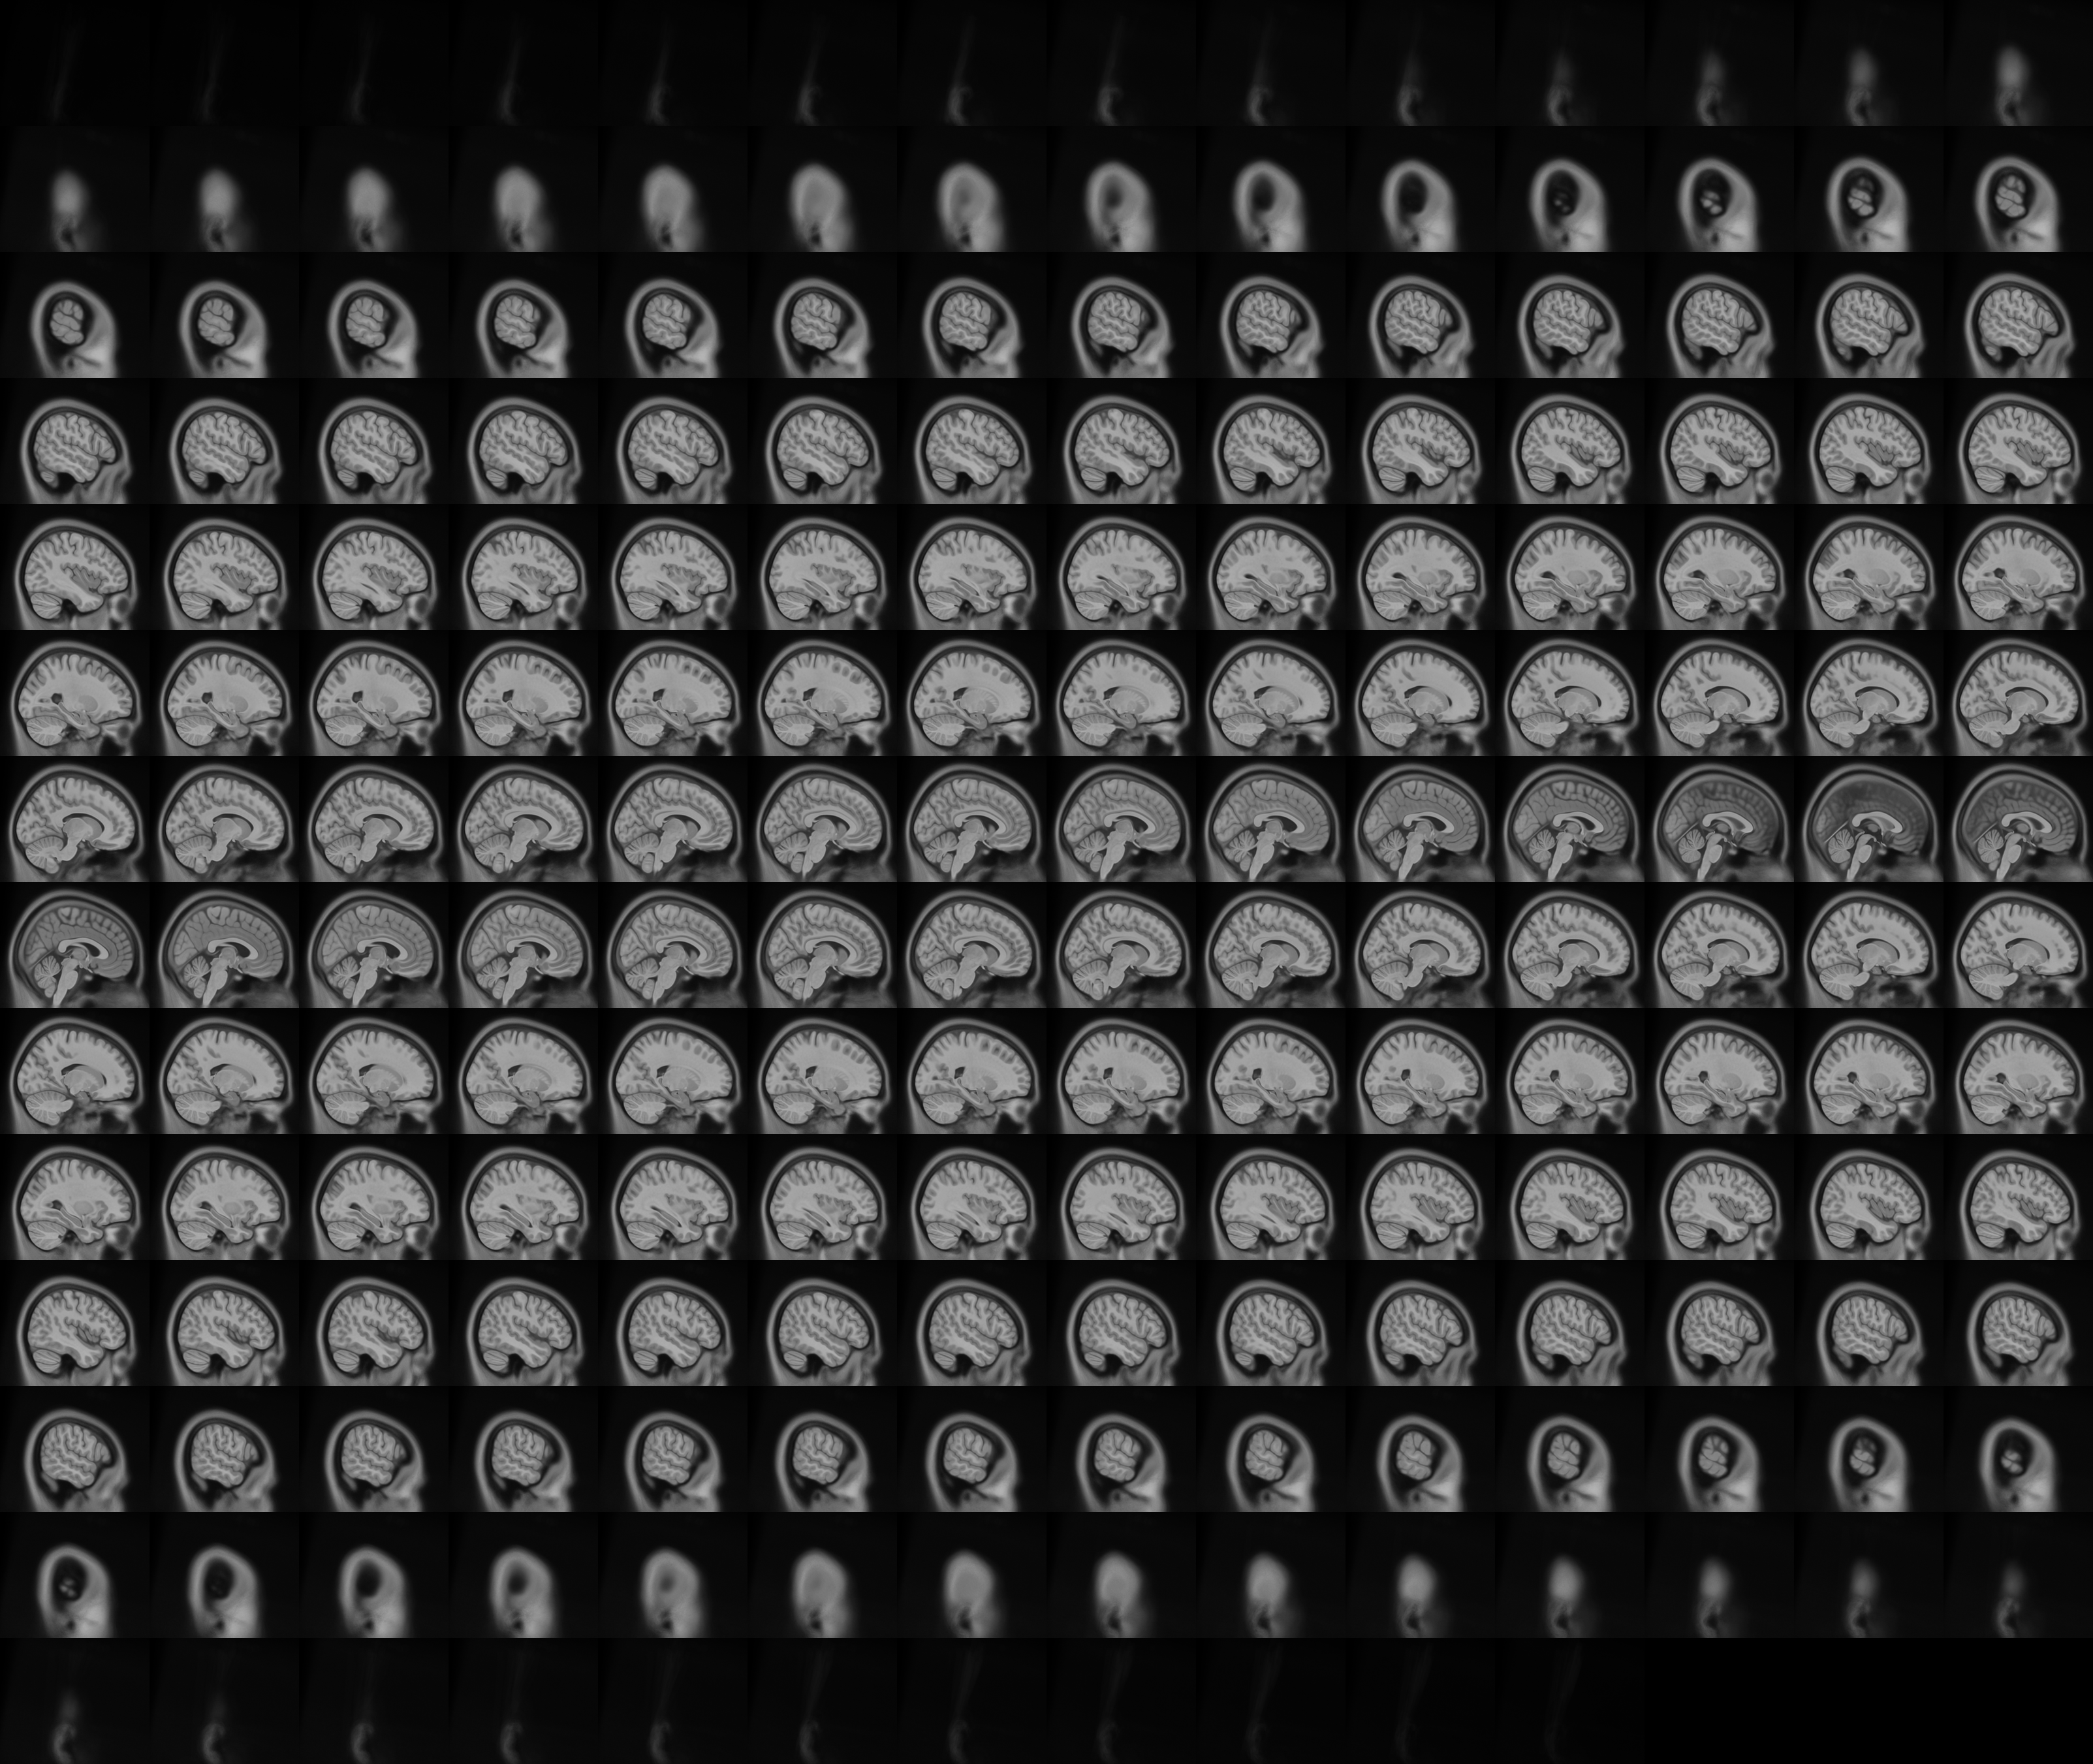
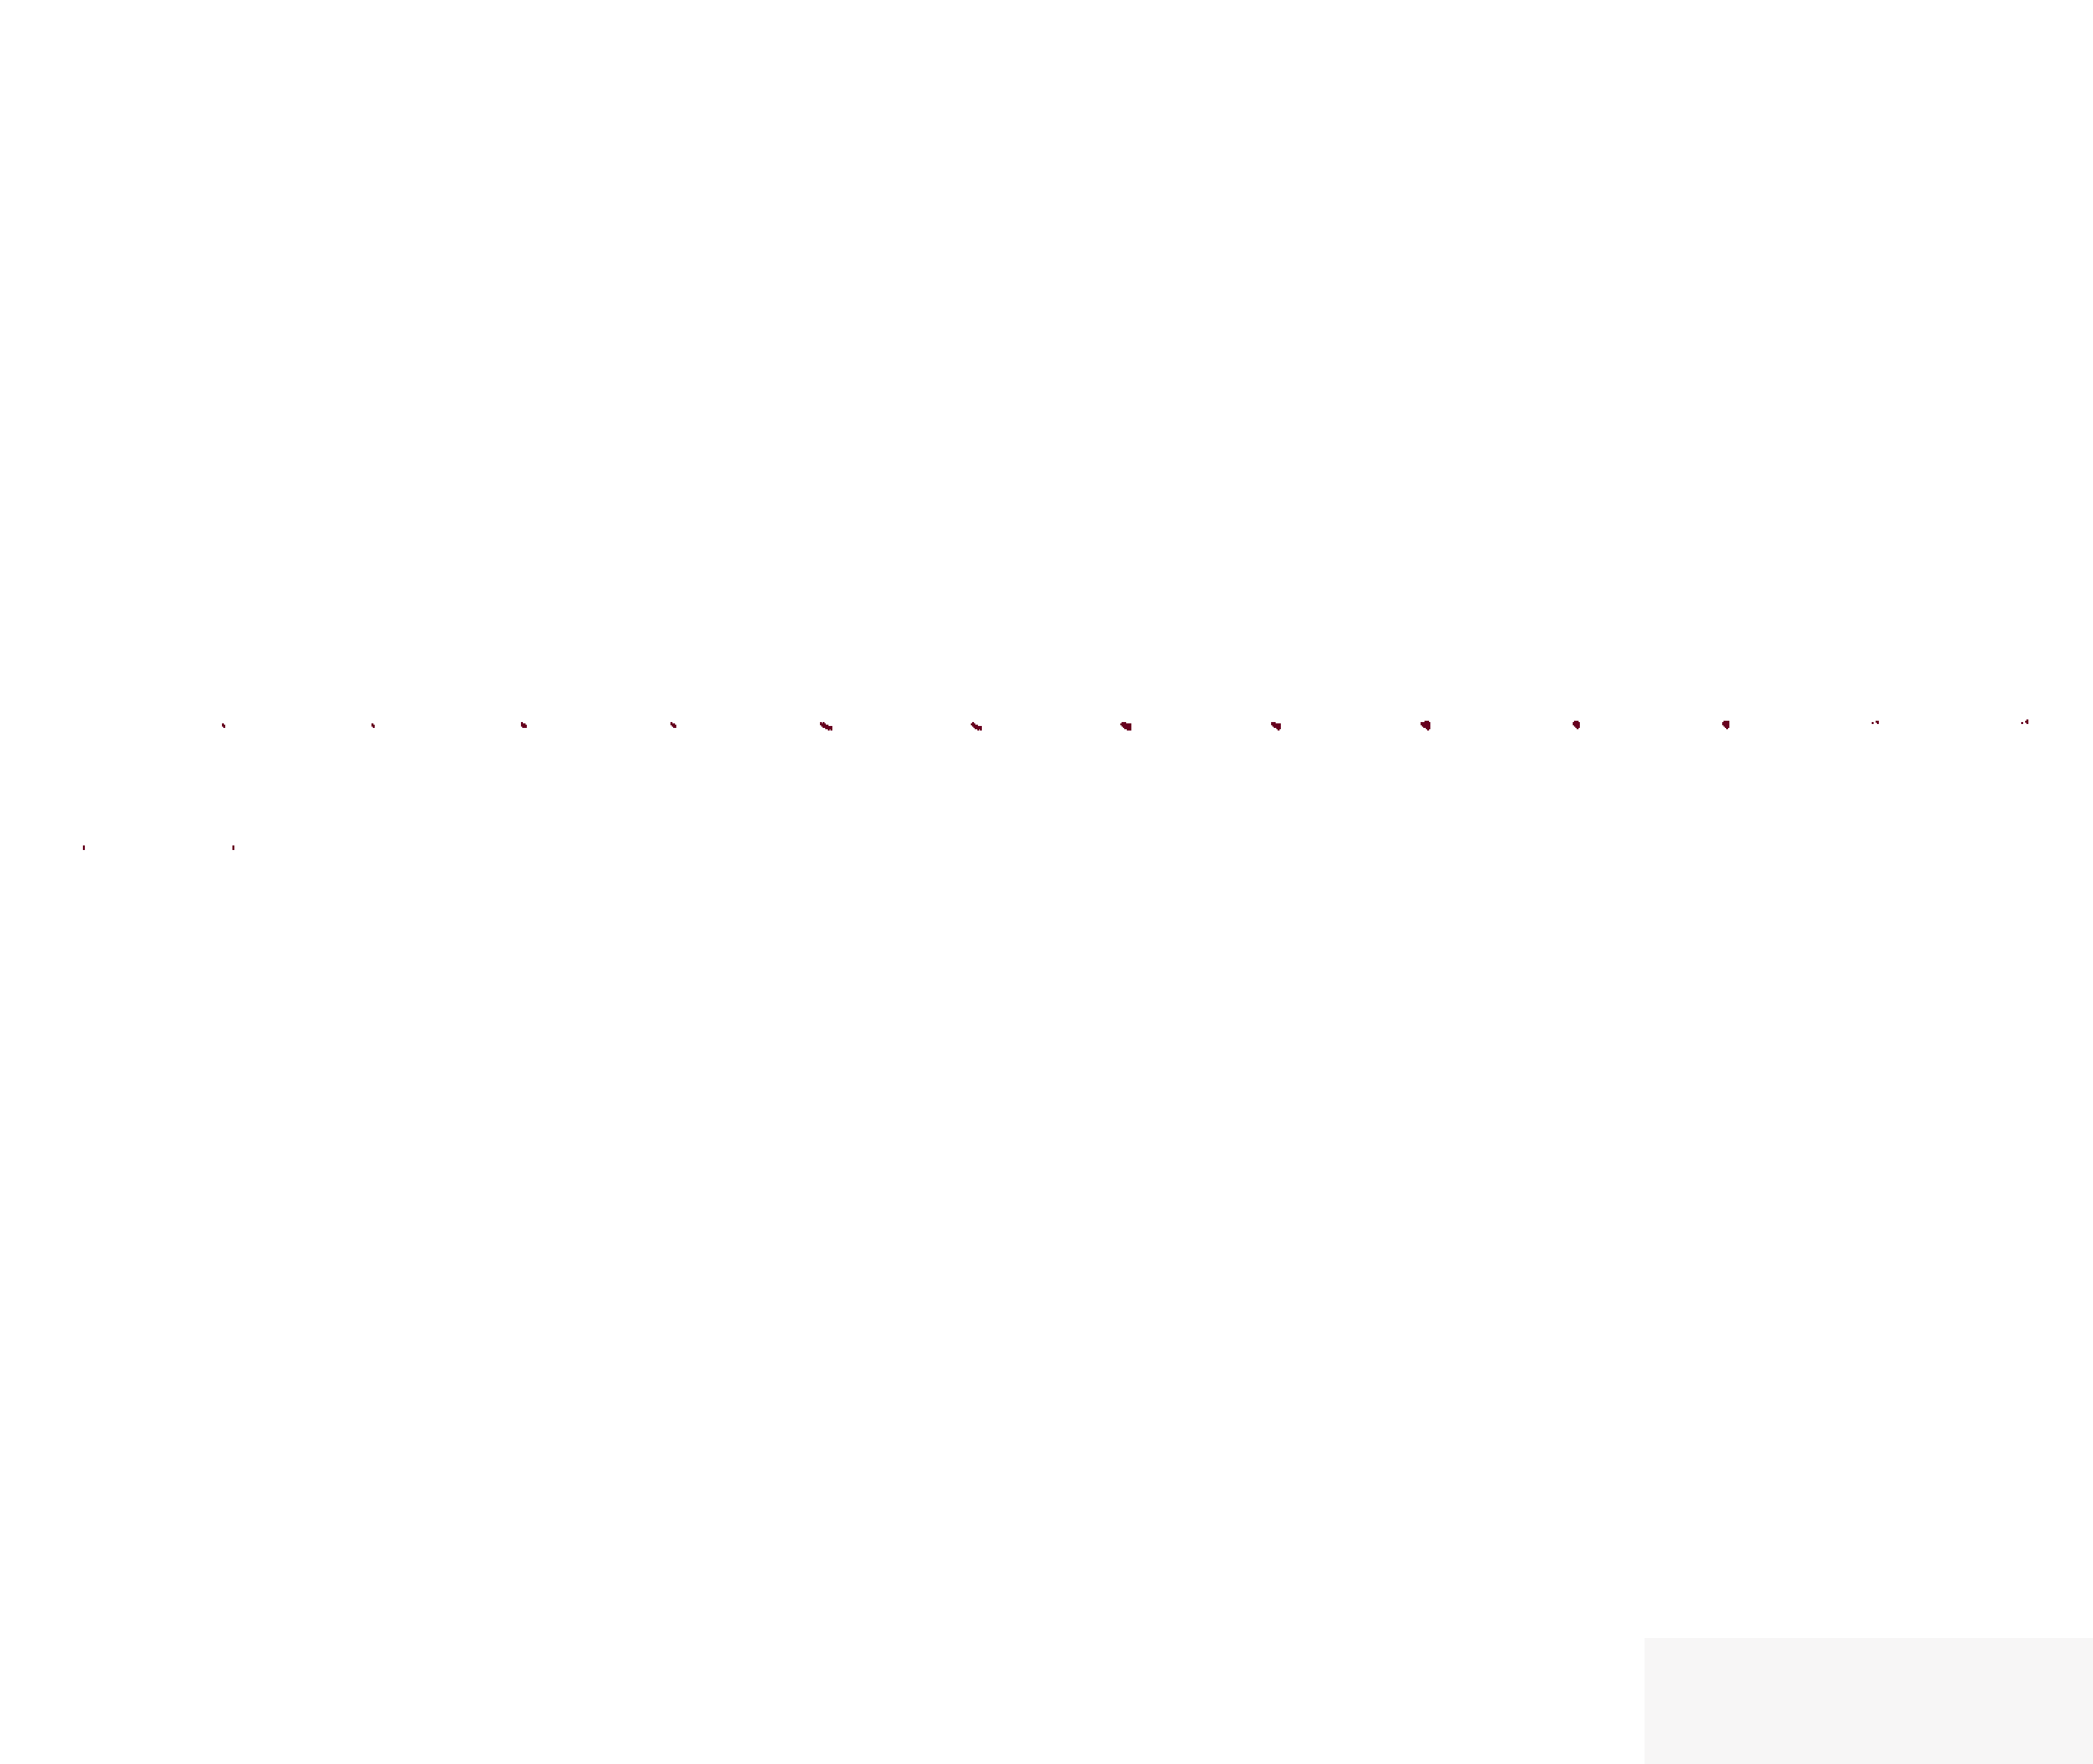


QC figure saved → alEC_PRCpref_left_Maass2015_mask_MNI_QC.png


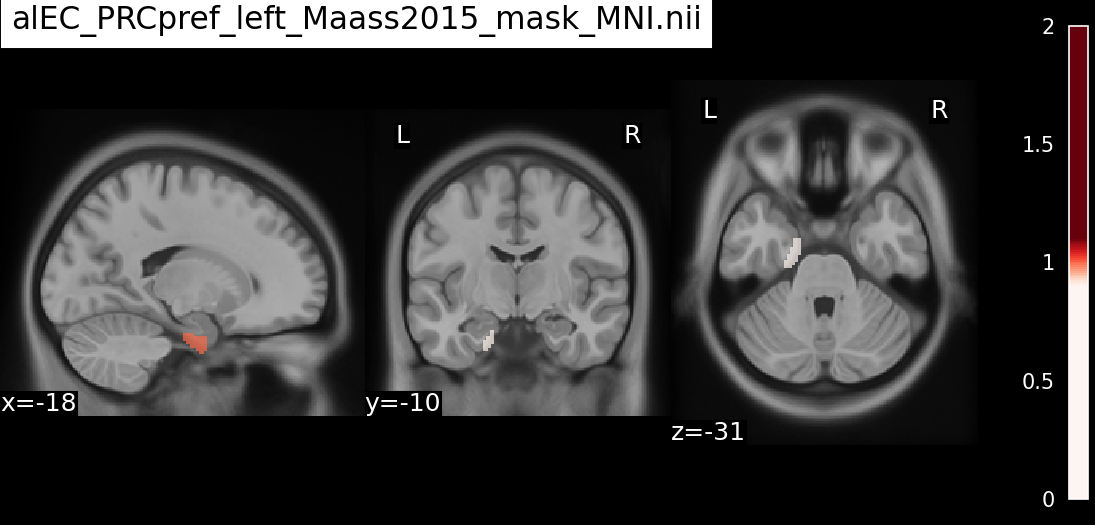

In [6]:
# -----------------------------------------------------------------------
# Step 2-QC — Visualise mask in MNI space
# Works for any mask in masks/standardized/.
# Renders an interactive nilearn viewer and a static tri-planar PNG.
# -----------------------------------------------------------------------

# ── Select mask to inspect ────────────────────────────────
QC_MASK_FILE = str(MASKS_STANDARD_DIR / "alEC_PRCpref_left_Maass2015_mask_MNI.nii.gz")
QC_THRESHOLD = 0.0   # 0.0 for binary; >0 for probabilistic / z-stat maps

# ── Verify space ──────────────────────────────────────────
qc_img   = nib.load(QC_MASK_FILE)
qc_shape = qc_img.shape
qc_vox   = np.abs(np.diag(qc_img.affine))[:3]

EXPECTED_SHAPE   = (193, 229, 193)
EXPECTED_SPACING = 1.0

shape_ok   = qc_shape == EXPECTED_SHAPE
spacing_ok = np.allclose(qc_vox, EXPECTED_SPACING, atol=0.01)

print(f"Mask: {Path(QC_MASK_FILE).name}")
print(f"  Shape:   {qc_shape}  {'✅' if shape_ok   else '❌  expected ' + str(EXPECTED_SHAPE)}")
print(f"  Spacing: {qc_vox.round(3)}  {'✅' if spacing_ok else '❌  expected 1.0 mm iso'}")
print(f"  Voxels > threshold: {int((qc_img.get_fdata() > QC_THRESHOLD).sum())}")

if not (shape_ok and spacing_ok):
    print("\n⚠️  Mask is NOT in MNI152NLin2009cAsym 1mm space — run step 2d to resample.")

# ── Interactive viewer ─────────────────────────────────────
mni_bg  = nib.load(t1_mni_path)
viewer  = plotting.view_img(
    QC_MASK_FILE,
    bg_img=mni_bg,
    opacity=0.7,
    threshold=QC_THRESHOLD,
    title=Path(QC_MASK_FILE).stem,
)
display(viewer)

# ── Static tri-planar PNG ──────────────────────────────────
fig = plotting.plot_roi(
    QC_MASK_FILE,
    bg_img=mni_bg,
    display_mode="ortho",
    draw_cross=False,
    title=Path(QC_MASK_FILE).stem,
    cmap="Reds",
    alpha=0.7,
)
qc_png = MASKS_STANDARD_DIR / (Path(QC_MASK_FILE).stem.replace(".nii", "") + "_QC.png")
fig.savefig(str(qc_png), dpi=150)
plt.close("all")
print(f"\nQC figure saved → {qc_png.name}")
display(IPImage(filename=str(qc_png)))